In [2]:
import pylab as plt
import numpy as np
from cartopy import crs as ccrs
from netCDF4 import Dataset
import xarray as xr
from scipy import ndimage
from scipy.optimize import minimize
from scipy.interpolate import interp1d

import sys as sys
sys.path.append('../src/')
import glob as glob
import datetime as datetime

import seismic_LOPS as seismic
import matplotlib.colors as mcolors
import cmocean
import cmocean.cm as cmo
lightcmap = cmo.thermal  #tools.lighten(cmo.deep, 2)

plt.rcParams.update({'font.size': 18,'savefig.facecolor':'white'})

In [7]:
wave_spectrum_2D='../data/waves/CCI_WW3-GLOB-30M-Ekoundou_2023_spec.nc'
# For the following file, you can get it here: https://data-ww3.ifremer.fr/PROJECT/CCI/RUNS/GLOB-30M/2023/FIELD_NC/CCI_WW3-GLOB-30M_202308_ef.nc
wave_spectrum_1D='../data/waves/CCI_WW3-GLOB-30M_202308_ef.nc'
depth_file='../data/depth/LOPS_WW3-GLOB-30M_dataref_dpt.nc'

ds = xr.open_dataset(depth_file)
dpt_full = ds.variables['dpt'].values

ds = xr.open_dataset(wave_spectrum_1D)
ef_full = ds.variables['ef']
lonmap = ds.variables['longitude']
latmap = ds.variables['latitude']
[nt,nf,ny,nx]=np.shape(ef_full)
print('dpt shape:',ny,nx)
dpt_map=np.squeeze(dpt_full[0:ny-1,:]) # crops strip of high latitudes that is not in ef file ... 
print('dpt shape:',np.shape(dpt_map))

bottom_topography_spectrum='../data/bottom/spectrum_Ireland_shallow_rocks.bsp'
dpt=30     # adjusts water depth
CgR  =1800 # group speed of seismic waves, assumed constant

ds = Dataset(wave_spectrum_2D, "r")
# list variables in the file
print(ds.variables.keys())
# read the frequency variable
freq = ds.variables["frequency"][:]
lat  = ds.variables["latitude"][0,0]
lon  = ds.variables["longitude"][0,0]
time_spec = ds.variables["time"][:]
date1=time_spec[0]
date2=time_spec[-1]
station='EDA'
dA=1E8*3600
Q=np.array(freq)*0+400
lato, lono, thresh1, thresh2, thresh3, maxd, r, network, startdate=seismic.station_info(freq, station)


# Define bounding box
lonmin, lonmax = -10, 10
latmin, latmax = -5, 10

indlon=np.where((lonmap >= lonmin) & (lonmap <= lonmax))[0]
indlat=np.where((latmap >= latmin) & (latmap <= latmax))[0]


F_delta,Fx_delta,Fy_delta,Ef_spec,freqp,df,times1=seismic.seismic_response_primary_sandwaves_spec(wave_spectrum_2D, bottom_topography_spectrum, dpt, lat,lon, CgR,  Q,  lono, lato, dA, station)
print('shape:',np.shape(F_delta))


F_delta1,botspec_map, k_map,map_source,freqp1,df1,times11=seismic.seismic_response_primary_sandwaves_ef_map(wave_spectrum_1D, bottom_topography_spectrum, dpt_map, indlon, indlat,  CgR,  Q,  lono, lato, dA, station)
print('shape:',np.shape(F_delta1))




dpt shape: 317 720
dpt shape: (323, 720)
dict_keys(['time', 'station', 'string40', 'station_name', 'longitude', 'latitude', 'frequency', 'frequency1', 'frequency2', 'direction', 'efth', 'dpt', 'wnd', 'wnddir', 'cur', 'curdir'])
alpha: 0.032050896612430074 1.1000000345150478
shape: (2920, 36)
SIZE: 744 36 317 720 3086419753.0864196
lon, lat, alpha; depth: 380 149 10.0 -3.5 0.12706839367894035 377.5
lon, lat, alpha; depth: 379 150 9.5 -3.0 0.11886128069714694 335.5
lon, lat, alpha; depth: 380 150 10.0 -3.0 0.11834383066656194 65.5
lon, lat, alpha; depth: 378 151 9.0 -2.5 0.1114185687768472 340.5
lon, lat, alpha; depth: 379 151 9.5 -2.5 0.1101780734207332 43.5
lon, lat, alpha; depth: 378 152 9.0 -2.0 0.10284752927778203 114.0
lon, lat, alpha; depth: 377 153 8.5 -1.5 0.09654251004657678 701.5
lon, lat, alpha; depth: 378 153 9.0 -1.5 0.09430492665261082 40.0
lon, lat, alpha; depth: 377 154 8.5 -1.0 0.08825259882461267 380.5
lon, lat, alpha; depth: 377 155 8.5 -0.5 0.08005531081110764 884.5


delta1: [1.47096740e-17 9.88920567e-17 6.97904599e-17 6.71354656e-17
 1.04901367e-15 7.53989149e-15 1.66238565e-14 1.75126461e-14
 1.87908018e-14 1.52766507e-14 8.38112917e-15 3.26528021e-15
 1.03843411e-15 3.72061423e-16 3.14908953e-16 3.32294308e-16
 2.69807205e-16 1.54225805e-16 5.94559777e-17 1.89286414e-17
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
sourceplot: nan


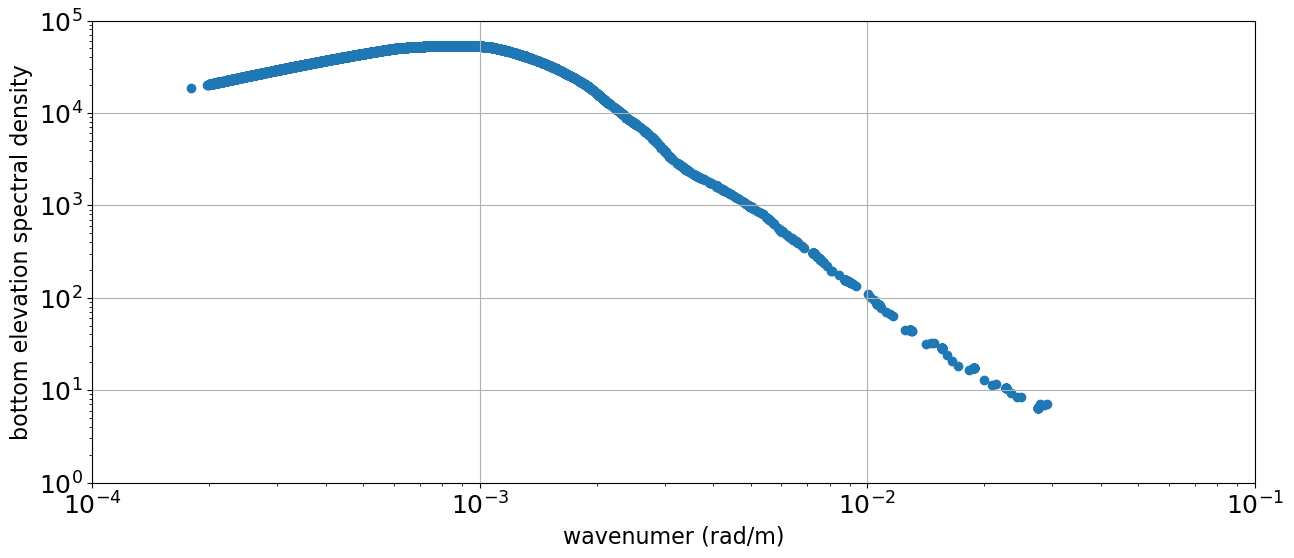

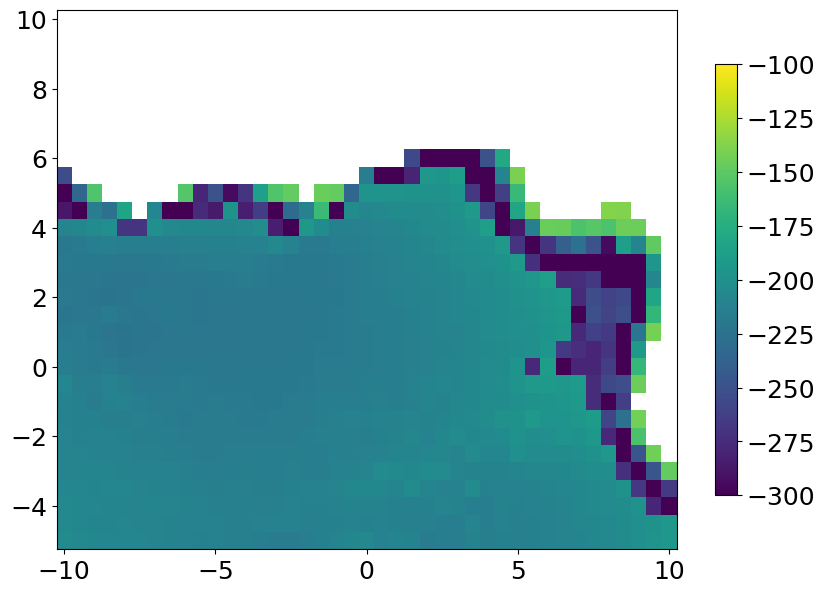

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,6))
P=60

ax.scatter(k_map/(2*np.pi), botspec_map*(2*np.pi))
ax.set_xlabel('wavenumer (rad/m)', fontsize=16)
ax.set_ylabel('bottom elevation spectral density', fontsize=16)
ax.set_yscale('log')  # ← this line sets log scale on y-axis
ax.set_xscale('log') 
ax.set_ylim([1,1E5])
ax.set_xlim([0.0001,0.10000])
plt.grid(True)

print('delta1:',F_delta1[0,:])
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(10,7))
sourceplot=map_source[7,:,:]
print('sourceplot:',sourceplot[-1,0])
im=ax.pcolormesh(lonmap[indlon],latmap[indlat],10*np.log10(sourceplot),cmap='viridis',rasterized=True, shading='nearest',vmin=-300, vmax=-100)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)


['2023-01-01T00:00:00'] ['2023-12-31T21:00:00']
['2023-01-01T00:00:00'] ['2023-12-31T21:00:00']
(53, 5400)
FRQ: (53,) [0.01166667 0.01333333 0.015      0.01666667 0.01833333 0.02
 0.02166667 0.02333333 0.025      0.02666667 0.02833333 0.03
 0.03166667 0.03333333 0.035      0.03666667 0.03833333 0.04
 0.04166667 0.04333333 0.045      0.04666667 0.04833333 0.05
 0.05166667 0.05333333 0.055      0.05666667 0.05833333 0.06
 0.06166667 0.06333333 0.065      0.06666667 0.06833333 0.07
 0.07166667 0.07333333 0.075      0.07666667 0.07833333 0.08
 0.08166667 0.08333333 0.085      0.08666667 0.08833333 0.09
 0.09166667 0.09333333]
SPEC: (5400, 53)
2023-01-01T00:00:00 2023-01-01T01:00:00 2024-01-01T22:59:59
(5400, 53) (5400,) (36,)
(2920, 36) (2920,) (36,)
(2920, 36) (2920,) (36,)
(744, 36) (2920,) (36,)
times11: 2023-08-01T00:00:00.000000000 2023-08-31T23:00:00.000000000 2023-08-01 2023-08-31
times11: 2023-08-01T00:00:00.000000000 2023-08-31T23:00:00.000000000 2023-08-01 2023-08-31 ## 1 719


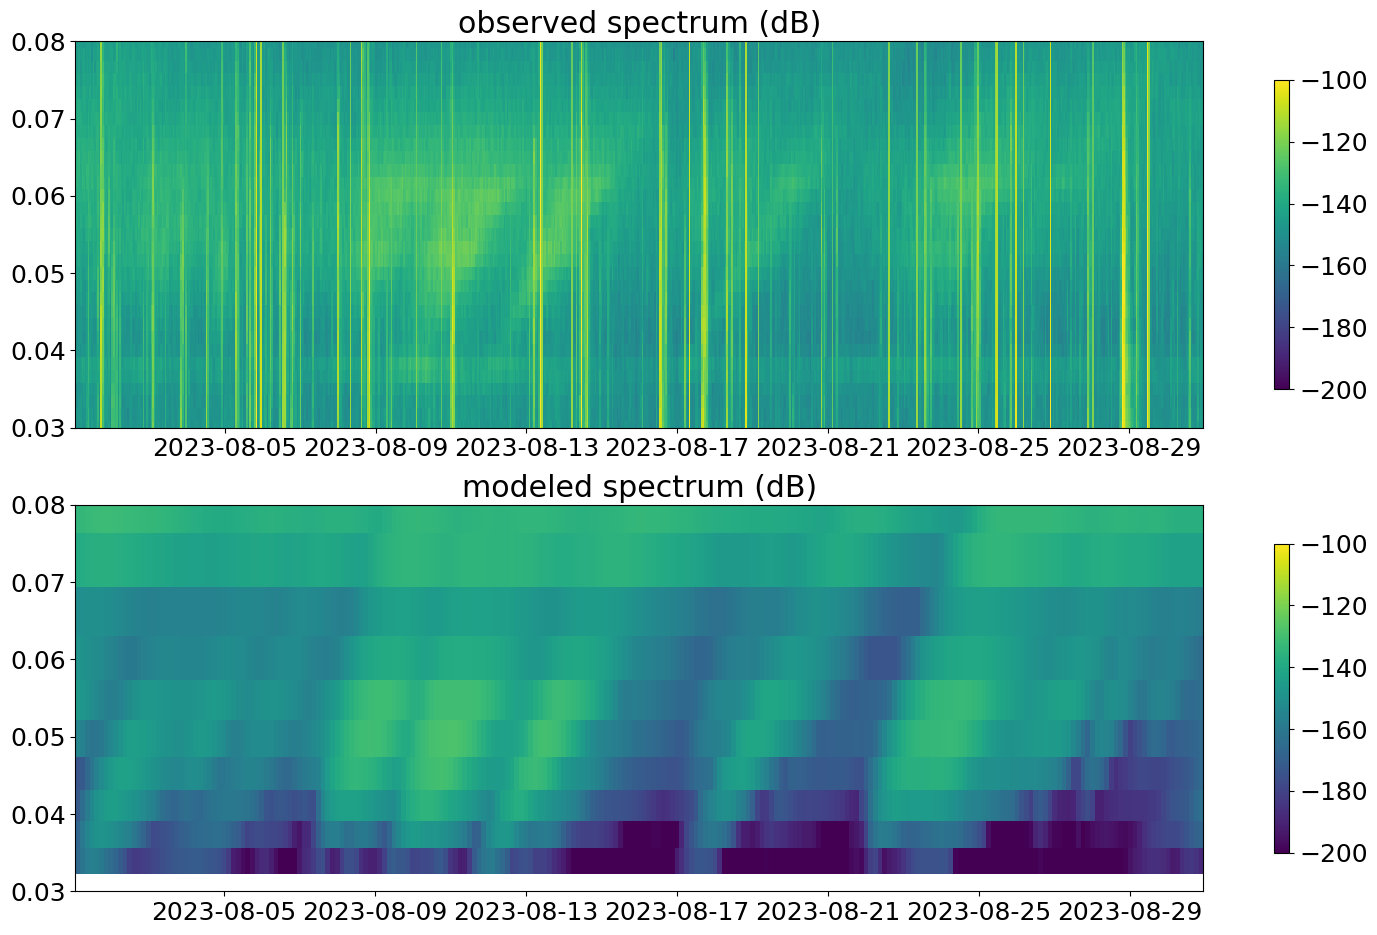

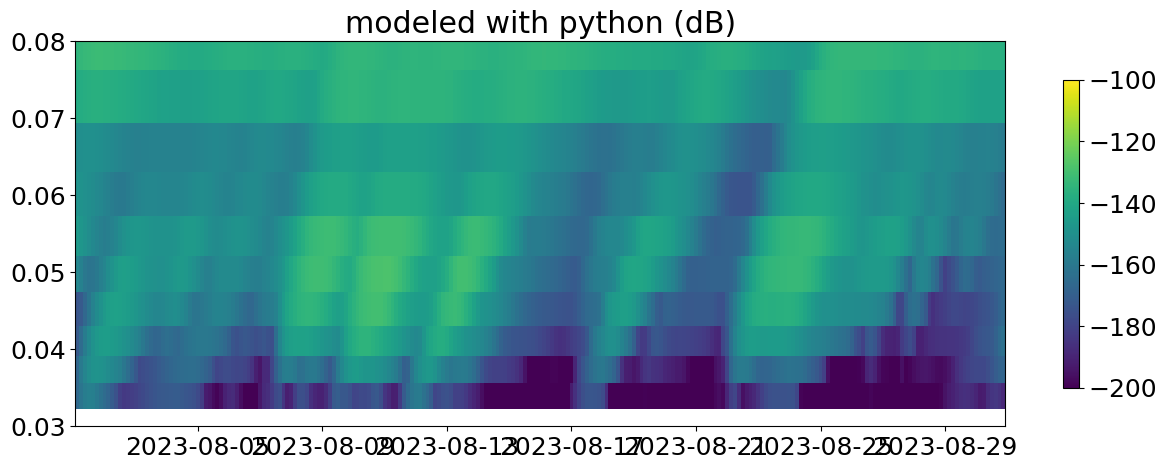

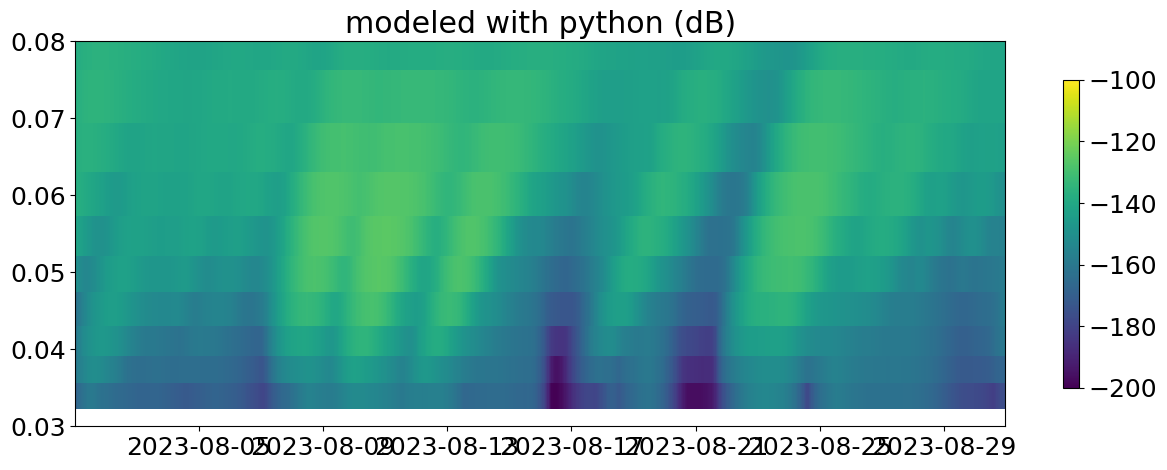

In [12]:
#times,freqp,Ef_pris,Q,lato,lono=import_synthetic_mat('EDA_PDC_GLOBAL05_202301_TEST471_REF102040Q400_150_primary.mat')
times,freqp,Ef_pris,Q,lato,lono=seismic.import_synthetic_mat('../data/primary_synthetic_matlab/EDA_IRL_GLOBAL05_202301_CCI_WW3_Ekoundou_Q400_030_primary.mat')
times,freqp,Ef_pri2,Q,lato,lono=seismic.import_synthetic_mat('../data/primary_synthetic_matlab/EDA_IRL_GLOBAL05_202301_CCI_WW3_Akpo_Q400_200_primary.mat')

# Warning: data from Piero is probably PSD of acceleration ... 
file='../data/seismic_PSDs/SpecEDA2023_psd.npz' # 'SpecEDA2023.npz'
date0, frq0, spectre0=seismic.read_sismo_npz(file)
print('FRQ:',np.shape(frq0),frq0[0:50])
print('SPEC:',np.shape(spectre0))
t1=np.datetime64('2023-08-01')
t2=np.datetime64('2023-08-31')
inds=np.where((date0 > t1) & (date0 < t2))[0]
print(date0[0],date0[1],date0[-1])
np.datetime64('2023-01-01')
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(15,10))
plt.subplots_adjust(left=0.05,bottom=0.07, top=0.92,wspace=0.12,right=0.99)
#im=ax[0].pcolormesh(10*np.log10(np.squeeze(spectre0)),cmap='viridis',rasterized=True) #,vmin=10, vmax=60)
print(np.shape(spectre0),np.shape(date0),np.shape(freqp))
im=ax[0].pcolormesh(date0[inds],frq0,10*np.log10(spectre0[inds,:].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax[0],label='', location='right',shrink=0.8)
_=ax[0].set_title('observed spectrum (dB)')
#_=ax[0].set_ylim([0.03,0.08])
_=ax[0].set_ylim([0.03,0.08])

print(np.shape(Ef_pris),np.shape(times),np.shape(freqp))
indsm=np.where((times > t1) & (times < t2))[0]
im=ax[1].pcolormesh(times[indsm],freqp[0:10],10*np.log10(3600*Ef_pris[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax[1],label='', location='right',shrink=0.8)
_=ax[1].set_title('modeled spectrum (dB)')
_=ax[1].set_ylim([0.03,0.08])


fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
print(np.shape(F_delta),np.shape(times),np.shape(freqp))
indsm=np.where((times1 > t1) & (times1 < t2))[0]
im=ax.pcolormesh(times1[indsm],freqp[0:10],10*np.log10(F_delta[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
print(np.shape(F_delta1),np.shape(times),np.shape(freqp))
print('times11:',times11[0].values,times11[-1].values,t1,t2)
indsm=np.where((times11 > t1) & (times11 < t2))[0]
print('times11:',times11[0].values,times11[-1].values,t1,t2,'##',indsm[0],indsm[-1])
im=ax.pcolormesh(times11[indsm],freqp1[0:10],10*np.log10(F_delta1[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

In [13]:
freqs=freqp
dfs=freqp*0.5*(1.1-1/1.1)
rs=dfs*0
print(lato,lono,freqs.shape)
# Set up paths
station='EDA' 
year=2023
yname = str(year)  # Replace with your desired year
#lato, lono, thresh1, thresh2, thresh3, maxd, rs, network, startdate=seismic.station_info(freqs, station)

ifmin = 1  # 0.1 
ifmax = 4 # 0.25

#ifmin = 5  # 0.1 
#ifmax = 8 # 0.25

print('Freq:',freqs[ifmin]*0.95,freqs[ifmax-1]*1.05)
# Assuming `date0` and `times` are datetime64 objects
base_date = np.datetime64('1970-01-01')  # You can use any base date, like '1970-01-01'

# Convert `date0` and `times` into seconds since the base date (this assumes `date0` and `times` are datetime64)
date0_seconds = (date0 - base_date) / np.timedelta64(1, 's')
times_seconds = (times - base_date) / np.timedelta64(1, 's')

# Now you can safely divide them by np.timedelta64(1, 's') if needed
delta_obs = seismic.compute_delta_obs(spectre0, frq0, freqs, ifmin, ifmax, date0_seconds, times_seconds,smooth=2,percentile=0)
delta_Eko, delta_ref = seismic.compute_delta_model(Ef_pris, Ef_pris, dfs, rs, ifmin, ifmax)
delta_Eko2, delta_ref = seismic.compute_delta_model(F_delta, F_delta, dfs, rs, ifmin, ifmax)
delta_map, delta_ref = seismic.compute_delta_model(F_delta1, F_delta1, dfs, rs, ifmin, ifmax)
delta_Akp, delta_ref = seismic.compute_delta_model(Ef_pri2, Ef_pri2, dfs, rs, ifmin, ifmax)





3.778868 10.153427 (36,)
Freq: 0.03542549945414066 0.04737694747745991
df2: (2920, 36)
df2: (2920, 36)
df2: (744, 36)
df2: (2920, 36)


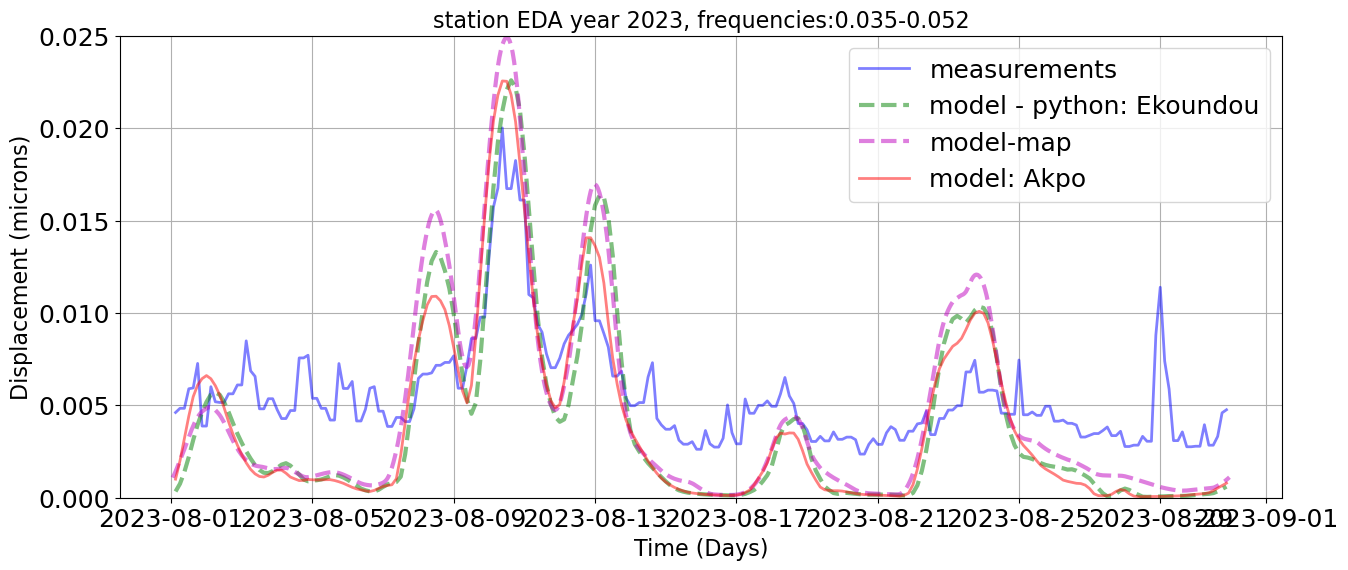

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,6))
P=30

t1=np.datetime64('2023-08-01')
t2=np.datetime64('2023-08-31')
inds=np.where((times > t1) & (times < t2))[0]
inds1=np.where((times11 > t1) & (times11 < t2))[0]

ax.plot(times[inds], delta_obs[inds], 'b-',alpha=0.5, label='measurements', linewidth=2)
ax.plot(times[inds], delta_Eko2[inds] , 'g--', alpha=0.5,label='model - python: Ekoundou', linewidth=3)
ax.plot(times11[inds1], delta_map[inds1] , 'm--', alpha=0.5,label='model-map', linewidth=3)
ax.plot(times[inds], delta_Akp[inds] * P, 'r-', alpha=0.5,label='model: Akpo', linewidth=2)
#ax.plot(times, delta_PDC * P, 'k-', alpha=0.5,label='model: sandwaves', linewidth=2)
ax.set_xlabel('Time (Days)', fontsize=16)
ax.set_ylabel('Displacement (microns)', fontsize=16)
ax.set_ylim([0,0.025])
freqstring=f'{freqs[ifmin]*0.95:4.3f}'+'-'+f'{freqs[ifmax]*1.05:4.3f}'
ax.set_title('station '+station+' year '+yname+ ', frequencies:'+freqstring, fontsize=16)
plt.legend()
plt.grid(True)
        
plt.savefig('timeseries_freqs_map'+freqstring+'.png')
